In [17]:
# Heart Failure Prediction — Logistic Regression Model

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)

In [18]:
#This block of code comes from the Train-Test Split File
heart_data = pd.read_csv("heart.csv")

heart_data['Sex_F'] = heart_data['Sex'].map({'M': 0, 'F': 1})
heart_data['ExerciseAngina'] = heart_data['ExerciseAngina'].map({'N': 0, 'Y': 1})
heart_data = heart_data.drop(columns=['Sex'])

heart_data['ChestPainType'] = pd.Categorical(heart_data['ChestPainType'], categories=['ASY', 'ATA', 'NAP', 'TA'])
heart_data['RestingECG'] = pd.Categorical(heart_data['RestingECG'], categories=['Normal', 'LVH', 'ST'])
heart_data['ST_Slope'] = pd.Categorical(heart_data['ST_Slope'], categories=['Up', 'Flat', 'Down'])

categorical_cols = ['ChestPainType', 'RestingECG', 'ST_Slope']
heart_data = pd.get_dummies(heart_data, columns=categorical_cols, drop_first=True, dtype=int)

feature_matrix = heart_data.drop("HeartDisease", axis=1)
target_labels = heart_data["HeartDisease"]

features_train, features_test, targets_train, targets_test = train_test_split(
    feature_matrix,
    target_labels,
    test_size=0.20,
    random_state=42,
    stratify= target_labels
)
scaler = StandardScaler()

# WWe 'fit' only on training data to prevent data leakage from the test set.
scaler.fit(features_train)

# We transform both sets using the training parameters so the scale is consistent.
features_train_scaled = scaler.transform(features_train)
features_test_scaled = scaler.transform(features_test)

In [19]:
logistic_regression_model = LogisticRegression(max_iter=5000, random_state=42)

logistic_regression_model.fit(features_train_scaled, targets_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [24]:
# Predictions
predicted_labels = logistic_regression_model.predict(features_test_scaled)

predicted_labels_prob = logistic_regression_model.predict_proba(features_test_scaled)[:, 1]

In [25]:
# Evaluation metrics
print("Logistic Regression Results")
print(f"  Accuracy  : {accuracy_score(targets_test, predicted_labels):.4f}")
print(f"  Precision : {precision_score(targets_test, predicted_labels):.4f}")
print(f"  Recall    : {recall_score(targets_test, predicted_labels):.4f}")
print(f"  F1-Score  : {f1_score(targets_test, predicted_labels):.4f}")
print(f"  ROC-AUC   : {roc_auc_score(targets_test, predicted_labels_prob):.4f}")

Logistic Regression Results
  Accuracy  : 0.8859
  Precision : 0.8716
  Recall    : 0.9314
  F1-Score  : 0.9005
  ROC-AUC   : 0.9293


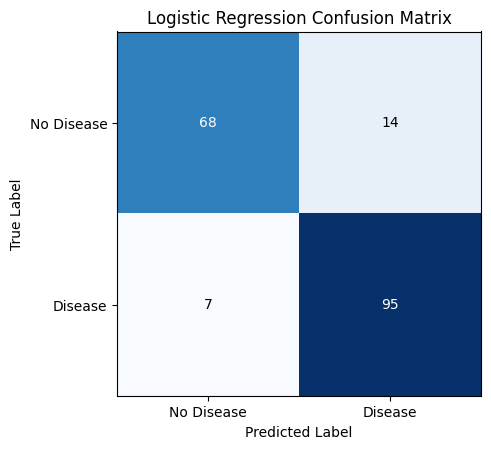

In [27]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Why: We generate a standard confusion matrix array to identify True/False Positives and Negatives.
cm = confusion_matrix(targets_test, predicted_labels)

# Why: figsize=(5,5) and the 2x2 nature of the data naturally create a square appearance.
fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)

# Why: Adding labels to the axes makes the matrix readable for medical professionals.
classes = ['No Disease', 'Disease']
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(classes)
ax.set_yticklabels(classes)

# Why: We loop through the matrix to place the actual counts in the center of each square.
# Why: The color 'white' or 'black' is chosen based on the background darkness for contrast.
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(cm[i, j], 'd'),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black")

ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_title('Logistic Regression Confusion Matrix')
plt.tight_layout()
plt.show()